# Results DR26 - More shocks

**Table of contents**<a id='toc0_'></a>    
- 1. [Load data                       ](#toc1_)    
- 2. [Simulated outcomes](#toc2_)    
- 3. [Convergence](#toc3_)    
  - 3.1. [Simple figure](#toc3_1_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # without this python may crash when plotting from matplotlib
import sys

from IPython.display import display, HTML

import numpy as np
import torch
import pandas as pd
from copy import deepcopy

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})
import matplotlib.lines as mlines

In [3]:
from BufferStockModel import BufferStockMoreShocksModelClass

In [4]:
parent_directory = os.path.abspath('..')
sys.path.append(parent_directory)
from plot_funcs import load_all, convergence_plot

## 1. <a id='toc1_'></a>[Load data](#toc2_)                        [&#8593;](#toc0_)

In [5]:
folder_load = '../output/'
folder = '../output/results'
algonames = ['DeepSimulate','DeepFOC'] 
Ds = [0]

In [6]:
labels = {
    'quad':'quad',
    'mc':'mc',
    'mcre':'mc + redraw',
    'mcanti':'mc + redraw + antithetic',
    'qmcanti':'sobol',
}

In [7]:
models = load_all(folder_load,'BufferStockMoreShocksModel')

DP 0D


DeepFOC mc


DeepFOC mcanti


DeepFOC mcre


DeepFOC qmcanti


DeepFOC quad


Check settings:

In [8]:
for label in labels:
    model = models[('DeepFOC',label)]
    par = model.par
    train = model.train
    print(f'{label:10s}: {train.use_quad = }, {train.redraw_mc = }, {par.do_antithetic_mc = :}, {par.use_sobol = :}, {par.Nmc = }')

quad      : train.use_quad = True, train.redraw_mc = False, par.do_antithetic_mc = True, par.use_sobol = False, par.Nmc = 100
mc        : train.use_quad = False, train.redraw_mc = False, par.do_antithetic_mc = False, par.use_sobol = False, par.Nmc = 200
mcre      : train.use_quad = False, train.redraw_mc = True, par.do_antithetic_mc = False, par.use_sobol = False, par.Nmc = 200
mcanti    : train.use_quad = False, train.redraw_mc = True, par.do_antithetic_mc = True, par.use_sobol = False, par.Nmc = 200
qmcanti   : train.use_quad = False, train.redraw_mc = False, par.do_antithetic_mc = True, par.use_sobol = True, par.Nmc = 200


Move simulation to numpy:

In [9]:
for model in models.values():
    for k,v in model.sim.__dict__.items():
        if isinstance(v,torch.Tensor):
            model.sim.__dict__[k] = v.numpy()

## 2. <a id='toc2_'></a>[Simulated outcomes](#toc2_) [&#8593;](#toc0_)

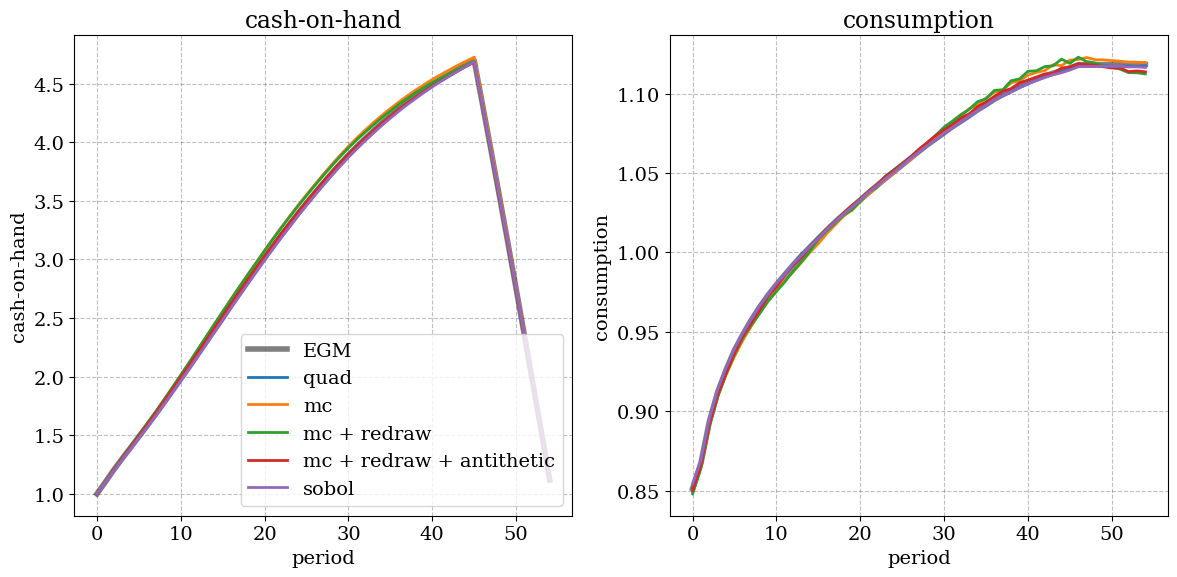

In [10]:
fig, ax = plt.subplots(ncols=2,figsize=(12,6))

ax[0].plot(np.mean(models[('DP','0D')].sim.states[:,:,0],axis=1),label='EGM',color='black',lw=4,alpha=0.5)
ax[1].plot(np.mean(models[('DP','0D')].sim.outcomes[:,:,0],axis=1),label='EGM',color='black',lw=4,alpha=0.5)

for i,(key,label) in enumerate(labels.items()):
    
    ax[0].plot(np.mean(models[('DeepFOC',key)].sim.states[:,:,0],axis=1),label=label,color=colors[i],lw=2)
    ax[1].plot(np.mean(models[('DeepFOC',key)].sim.outcomes[:,:,0],axis=1),label=label,color=colors[i],lw=2)

ax[0].legend()
ax[0].set_xlabel('period')
ax[0].set_ylabel('cash-on-hand')
ax[0].set_title('cash-on-hand')

ax[1].set_xlabel('period')
ax[1].set_ylabel('consumption')
ax[1].set_title('consumption')

fig.tight_layout()
fig.savefig(f'{folder}/BufferStockMoreShocksModel_lcp.svg')

## 3. <a id='toc3_'></a>[Convergence](#toc2_) [&#8593;](#toc0_)

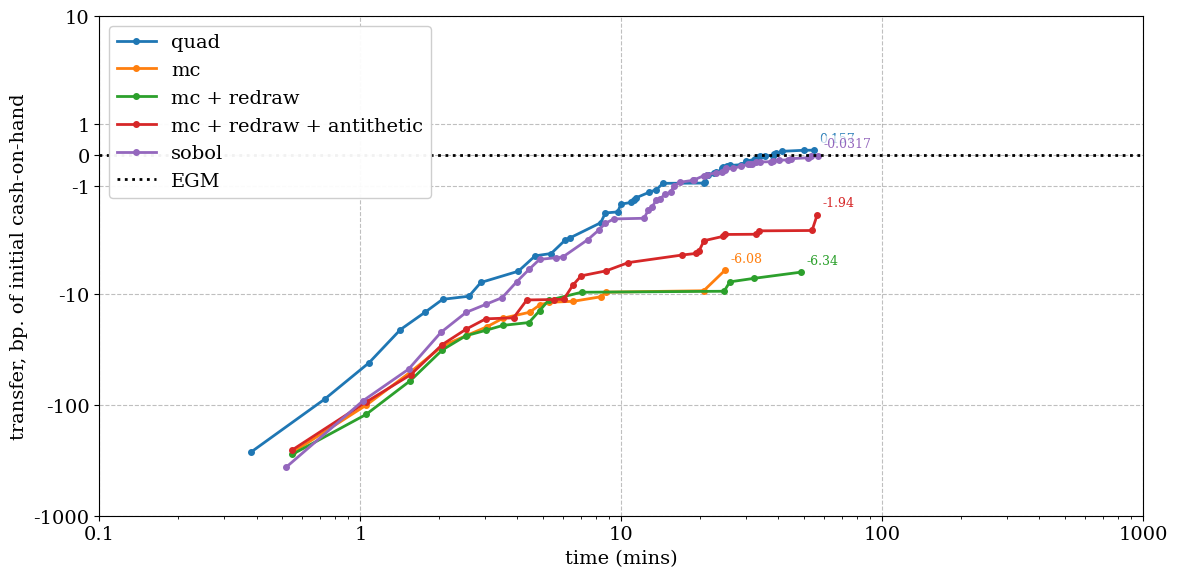

In [11]:
xlim = [0.1,1000]
specs = {('DeepFOC',key):label for key,label in labels.items()}
convergence_plot('BufferStockMoreShocksModel',models,specs,DP=models[('DP','0D')],do_transfer=True,
                    xlim=xlim,ylim=[None,10],legend_ncol=1,
                    folder=folder,postfix=f'_conv')

### 3.1. <a id='toc3_1_'></a>[Simple figure](#toc0_)

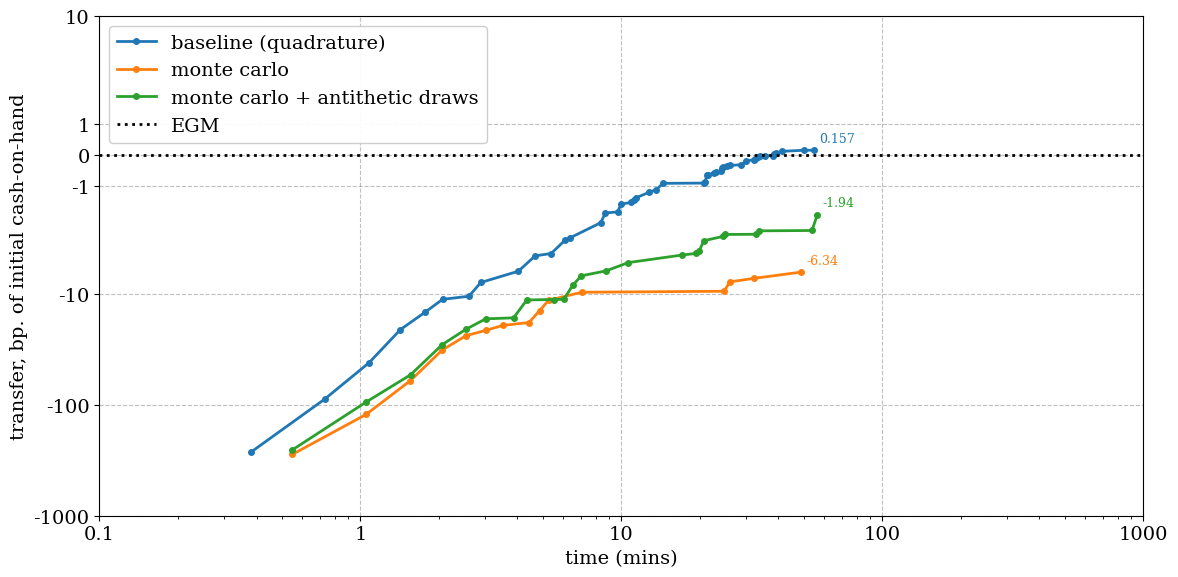

In [12]:
labels_new = {
    'quad':'baseline (quadrature)',
    'mcre':'monte carlo',
    'mcanti':'monte carlo + antithetic draws',    
}

xlim = [0.1,1000]
specs = {('DeepFOC',key):label for key,label in labels_new.items()}

convergence_plot('BufferStockMoreShocksModel',models,specs,DP=models[('DP','0D')],do_transfer=True,
                    xlim=xlim,ylim=[None,10],legend_ncol=1,
                    folder=folder,postfix=f'_conv_simple')